In [1]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

from xgboost import XGBClassifier

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
FEATURE_COLUMNS = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud",
    
    "user_transaction_count_before",
    "previous_transaction_amount",
    "time_since_previous_transaction",
    "previous_average_amount",
    "amount_deviation",
    "amount_to_previous_average",
    "balance_depletion",
    "amount_to_balance_ratio"
]

TARGET = "isFraud"

In [4]:
train_columns = FEATURE_COLUMNS + [TARGET]

train_df = pd.read_csv(
    "../data/processed/train_data.csv",
    usecols=train_columns
)

print(train_df.shape)

(6082007, 16)


In [5]:
print(train_df.head())

   step    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1   9839.64       170136.0       160296.36             0.0   
1     1   1864.28        21249.0        19384.72             0.0   
2     1    181.00          181.0            0.00             0.0   
3     1    181.00          181.0            0.00         21182.0   
4     1  11668.14        41554.0        29885.86             0.0   

   newbalanceDest  isFraud  isFlaggedFraud  user_transaction_count_before  \
0             0.0        0               0                              0   
1             0.0        0               0                              0   
2             0.0        1               0                              0   
3             0.0        1               0                              0   
4             0.0        0               0                              0   

   previous_transaction_amount  time_since_previous_transaction  \
0                          NaN                              N

In [6]:
print(train_df[TARGET].value_counts())

isFraud
0    6076226
1       5781
Name: count, dtype: int64


In [7]:
negative_count = (train_df[TARGET] == 0).sum()
positive_count = (train_df[TARGET] == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative:", negative_count)
print("Positive:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative: 6076226
Positive: 5781
scale_pos_weight: 1051.0683272790175


In [8]:
X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (6082007, 15)
y_train: (6082007,)


In [9]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)


In [10]:
validation_df = pd.read_csv(
    "../data/processed/validation_data.csv",
    usecols=FEATURE_COLUMNS + [TARGET]
)

print(validation_df.shape)

(191147, 16)


In [11]:
X_validation = validation_df[FEATURE_COLUMNS]
y_validation = validation_df[TARGET]

print("Validation:", X_validation.shape)

Validation: (191147, 15)


In [12]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=True
)

[0]	validation_0-aucpr:0.73218
[1]	validation_0-aucpr:0.97493
[2]	validation_0-aucpr:0.97565
[3]	validation_0-aucpr:0.97497
[4]	validation_0-aucpr:0.97514
[5]	validation_0-aucpr:0.97539
[6]	validation_0-aucpr:0.97563
[7]	validation_0-aucpr:0.97562
[8]	validation_0-aucpr:0.97566
[9]	validation_0-aucpr:0.97565
[10]	validation_0-aucpr:0.97567
[11]	validation_0-aucpr:0.97564
[12]	validation_0-aucpr:0.97432
[13]	validation_0-aucpr:0.97441
[14]	validation_0-aucpr:0.97424
[15]	validation_0-aucpr:0.97342
[16]	validation_0-aucpr:0.97350
[17]	validation_0-aucpr:0.97352
[18]	validation_0-aucpr:0.97361
[19]	validation_0-aucpr:0.97373
[20]	validation_0-aucpr:0.97377
[21]	validation_0-aucpr:0.97385
[22]	validation_0-aucpr:0.97390
[23]	validation_0-aucpr:0.97388
[24]	validation_0-aucpr:0.97368
[25]	validation_0-aucpr:0.97375
[26]	validation_0-aucpr:0.97381
[27]	validation_0-aucpr:0.97384
[28]	validation_0-aucpr:0.97367
[29]	validation_0-aucpr:0.97387
[30]	validation_0-aucpr:0.97401
[31]	validation_0-

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [13]:
validation_probabilities = model.predict_proba(
    X_validation
)[:, 1]

print(validation_probabilities[:20])

[9.9992621e-01 9.9970585e-01 9.9999964e-01 9.9999905e-01 9.9986768e-01
 9.9988306e-01 9.9998593e-01 9.9958295e-01 9.9999809e-01 9.9989259e-01
 9.9917138e-01 9.9950397e-01 9.9922967e-01 9.9935204e-01 4.8832840e-06
 3.1014176e-06 1.5761435e-06 2.0156827e-08 3.8171975e-06 5.1629027e-06]


In [14]:
pr_auc = average_precision_score(
    y_validation,
    validation_probabilities
)

print("Validation PR-AUC:", pr_auc)

Validation PR-AUC: 0.9771276026104758


In [15]:
roc_auc = roc_auc_score(
    y_validation,
    validation_probabilities
)

print("Validation ROC-AUC:", roc_auc)

Validation ROC-AUC: 0.9998583384643167


In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:

    predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        predictions,
        zero_division=0
    )

    print(
        f"Threshold={threshold:.1f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f}"
    )

Threshold=0.1 | Precision=0.8033 | Recall=1.0000 | F1=0.8909
Threshold=0.2 | Precision=0.8057 | Recall=0.9983 | F1=0.8917
Threshold=0.3 | Precision=0.8080 | Recall=0.9983 | F1=0.8931
Threshold=0.4 | Precision=0.8096 | Recall=0.9983 | F1=0.8941
Threshold=0.5 | Precision=0.8102 | Recall=0.9983 | F1=0.8945


In [17]:
BEST_THRESHOLD = 0.5

print("Selected baseline threshold:", BEST_THRESHOLD)

Selected baseline threshold: 0.5


In [18]:
test_df = pd.read_csv(
    "../data/processed/test_data.csv",
    usecols=FEATURE_COLUMNS + [TARGET]
)

print(test_df.shape)

(89466, 16)


In [19]:
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET]

print("Test shape:", X_test.shape)
print("Fraud cases:", y_test.sum())

Test shape: (89466, 15)
Fraud cases: 1252


In [20]:
test_probabilities = model.predict_proba(
    X_test
)[:, 1]

print(test_probabilities[:20])

[0.9999969  0.9999492  0.99985385 0.9997862  0.99999714 0.9998292
 0.99992275 0.99953806 0.99993634 0.999843   0.99999964 0.99998677
 0.99999714 0.9999001  0.9999815  0.99964976 0.9999685  0.999828
 0.99728215 0.99860793]


In [21]:
test_pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

print("Test PR-AUC:", test_pr_auc)
print("Test ROC-AUC:", test_roc_auc)

Test PR-AUC: 0.9880938293750128
Test ROC-AUC: 0.9998394841588757


In [22]:
test_predictions = (
    test_probabilities >= BEST_THRESHOLD
).astype(int)

In [23]:
test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1:", test_f1)

Test Precision: 0.8968481375358166
Test Recall: 1.0
Test F1: 0.945619335347432


In [24]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

print(cm)

[[88070   144]
 [    0  1252]]


In [25]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)



              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     88214
       Fraud       0.90      1.00      0.95      1252

    accuracy                           1.00     89466
   macro avg       0.95      1.00      0.97     89466
weighted avg       1.00      1.00      1.00     89466



In [26]:
print("Test PR-AUC:", test_pr_auc)
print("Test ROC-AUC:", test_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_predictions))

Test PR-AUC: 0.9880938293750128
Test ROC-AUC: 0.9998394841588757

Confusion Matrix:
[[88070   144]
 [    0  1252]]


In [28]:
import os

os.makedirs("../models_saved", exist_ok=True)

MODEL_FILE = "../models_saved/xgboost_model.json"

model.save_model(MODEL_FILE)

print("Model saved successfully:")
print(MODEL_FILE)

Model saved successfully:
../models_saved/xgboost_model.json


In [29]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [30]:
X_explain = X_test.iloc[:500].copy()

print(X_explain.shape)

(500, 15)


In [31]:
explainer = shap.TreeExplainer(model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [32]:
shap_values = explainer.shap_values(X_explain)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (500, 15)


In [33]:
shap_importance = pd.DataFrame({
    "feature": X_explain.columns,
    "importance": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "importance",
    ascending=False
)

print(shap_importance)

                            feature  importance
14          amount_to_balance_ratio    4.140821
3                    newbalanceOrig    3.442353
13                balance_depletion    3.248910
1                            amount    1.717945
2                     oldbalanceOrg    1.010778
0                              step    0.856678
4                    oldbalanceDest    0.726133
5                    newbalanceDest    0.609724
6                    isFlaggedFraud    0.020744
11                 amount_deviation    0.011994
9   time_since_previous_transaction    0.005814
8       previous_transaction_amount    0.004768
10          previous_average_amount    0.001790
12       amount_to_previous_average    0.001691
7     user_transaction_count_before    0.000268


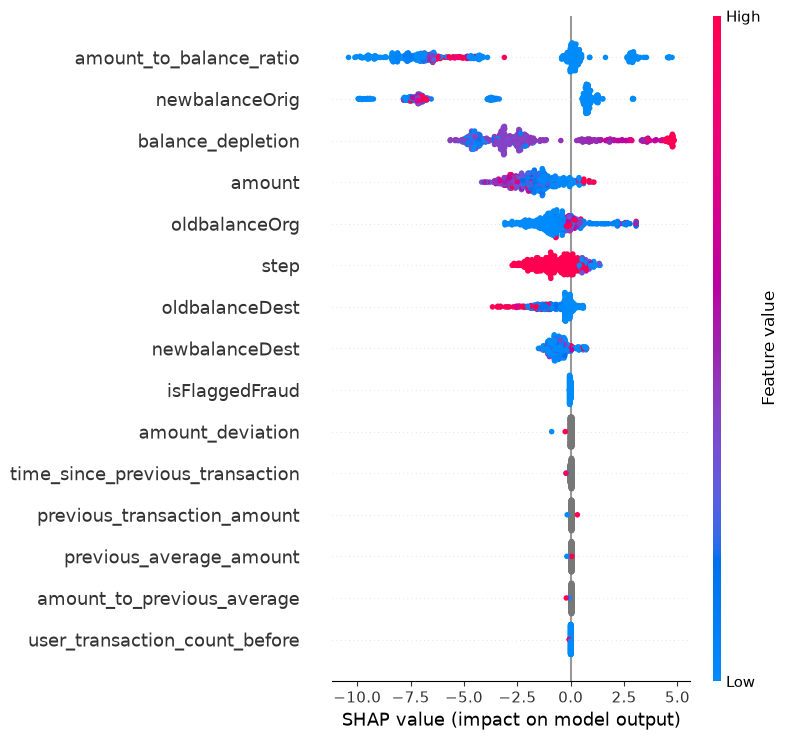

In [34]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_explain,
    show=True
)

In [35]:
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [36]:
import shap

explainer = shap.TreeExplainer(model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [37]:
X_explain = X_test.iloc[:500].copy()

print("Explanation sample:", X_explain.shape)

Explanation sample: (500, 15)


In [38]:
shap_values = explainer.shap_values(X_explain)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (500, 15)


In [39]:
shap_importance = pd.DataFrame({
    "feature": X_explain.columns,
    "importance": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "importance",
    ascending=False
)

print(shap_importance)

                            feature  importance
14          amount_to_balance_ratio    4.140821
3                    newbalanceOrig    3.442353
13                balance_depletion    3.248910
1                            amount    1.717945
2                     oldbalanceOrg    1.010778
0                              step    0.856678
4                    oldbalanceDest    0.726133
5                    newbalanceDest    0.609724
6                    isFlaggedFraud    0.020744
11                 amount_deviation    0.011994
9   time_since_previous_transaction    0.005814
8       previous_transaction_amount    0.004768
10          previous_average_amount    0.001790
12       amount_to_previous_average    0.001691
7     user_transaction_count_before    0.000268


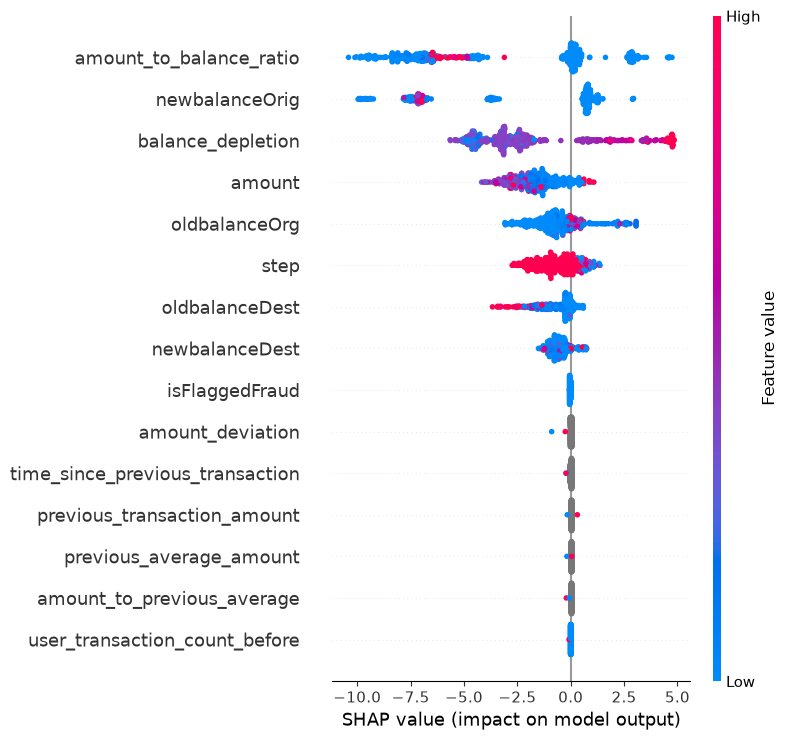

In [40]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_explain,
    show=True
)

In [1]:
FEATURE_COLUMNS_NEW = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud",

    # Sender behaviour
    "user_transaction_count_before",
    "previous_transaction_amount",
    "time_since_previous_transaction",
    "previous_average_amount",
    "amount_deviation",
    "amount_to_previous_average",

    # Balance behaviour
    "balance_depletion",
    "amount_to_balance_ratio",

    # Receiver behaviour
    "receiver_transaction_count_before",
    "receiver_previous_amount",
    "receiver_transaction_frequency",

    # Transaction type behaviour
    "user_transfer_count_before",
    "user_cashout_count_before",

    # Velocity
    "transaction_velocity"
]

TARGET = "isFraud"

print("Number of ML features:", len(FEATURE_COLUMNS_NEW))

Number of ML features: 21


In [6]:
import pandas as pd
print("Total columns in train dataset:")

train_check = pd.read_csv(
    "../data/processed/train_data.csv",
    nrows=5
)

print(train_check.columns.tolist())

print("\nTotal columns:", len(train_check.columns))

Total columns in train dataset:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'user_transaction_count_before', 'previous_transaction_amount', 'time_since_previous_transaction', 'previous_average_amount', 'amount_deviation', 'amount_to_previous_average', 'balance_depletion', 'amount_to_balance_ratio', 'receiver_transaction_count_before', 'receiver_previous_amount', 'receiver_transaction_frequency', 'user_transfer_count_before', 'user_cashout_count_before', 'transaction_velocity']

Total columns: 25


In [7]:
print("ML features:")
for i, feature in enumerate(FEATURE_COLUMNS_NEW, start=1):
    print(i, feature)

print("\nNumber of ML features:", len(FEATURE_COLUMNS_NEW))

ML features:
1 step
2 amount
3 oldbalanceOrg
4 newbalanceOrig
5 oldbalanceDest
6 newbalanceDest
7 isFlaggedFraud
8 user_transaction_count_before
9 previous_transaction_amount
10 time_since_previous_transaction
11 previous_average_amount
12 amount_deviation
13 amount_to_previous_average
14 balance_depletion
15 amount_to_balance_ratio
16 receiver_transaction_count_before
17 receiver_previous_amount
18 receiver_transaction_frequency
19 user_transfer_count_before
20 user_cashout_count_before
21 transaction_velocity

Number of ML features: 21


In [8]:
print("Expected feature list:")

FEATURE_COLUMNS_NEW = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud",
    "user_transaction_count_before",
    "previous_transaction_amount",
    "time_since_previous_transaction",
    "previous_average_amount",
    "amount_deviation",
    "amount_to_previous_average",
    "balance_depletion",
    "amount_to_balance_ratio",
    "receiver_transaction_count_before",
    "receiver_previous_amount",
    "receiver_transaction_frequency",
    "user_transfer_count_before",
    "user_cashout_count_before",
    "transaction_velocity"
]

print("Number of ML features:", len(FEATURE_COLUMNS_NEW))

Expected feature list:
Number of ML features: 21


In [9]:
print("ML features:")
for i, feature in enumerate(FEATURE_COLUMNS_NEW, start=1):
    print(i, feature)

print("\nNumber of ML features:", len(FEATURE_COLUMNS_NEW))

ML features:
1 step
2 amount
3 oldbalanceOrg
4 newbalanceOrig
5 oldbalanceDest
6 newbalanceDest
7 isFlaggedFraud
8 user_transaction_count_before
9 previous_transaction_amount
10 time_since_previous_transaction
11 previous_average_amount
12 amount_deviation
13 amount_to_previous_average
14 balance_depletion
15 amount_to_balance_ratio
16 receiver_transaction_count_before
17 receiver_previous_amount
18 receiver_transaction_frequency
19 user_transfer_count_before
20 user_cashout_count_before
21 transaction_velocity

Number of ML features: 21


In [10]:
train_check = pd.read_csv(
    "../data/processed/train_data.csv",
    nrows=5
)

print("All 25 columns:")
for i, column in enumerate(train_check.columns, start=1):
    print(i, column)

All 25 columns:
1 step
2 type
3 amount
4 nameOrig
5 oldbalanceOrg
6 newbalanceOrig
7 nameDest
8 oldbalanceDest
9 newbalanceDest
10 isFraud
11 isFlaggedFraud
12 user_transaction_count_before
13 previous_transaction_amount
14 time_since_previous_transaction
15 previous_average_amount
16 amount_deviation
17 amount_to_previous_average
18 balance_depletion
19 amount_to_balance_ratio
20 receiver_transaction_count_before
21 receiver_previous_amount
22 receiver_transaction_frequency
23 user_transfer_count_before
24 user_cashout_count_before
25 transaction_velocity


In [11]:
non_feature_columns = [
    column
    for column in train_check.columns
    if column not in FEATURE_COLUMNS_NEW
]

print("Columns not currently in FEATURE_COLUMNS_NEW:")
print(non_feature_columns)

Columns not currently in FEATURE_COLUMNS_NEW:
['type', 'nameOrig', 'nameDest', 'isFraud']


In [12]:
print(train_check["type"].value_counts())

type
PAYMENT     3
TRANSFER    1
CASH_OUT    1
Name: count, dtype: int64


In [13]:
train_df_new = pd.read_csv(
    "../data/processed/train_data.csv"
)

validation_df_new = pd.read_csv(
    "../data/processed/validation_data.csv"
)

print("Train shape:", train_df_new.shape)
print("Validation shape:", validation_df_new.shape)

Train shape: (6082007, 25)
Validation shape: (191147, 25)


In [14]:
train_df_new = pd.get_dummies(
    train_df_new,
    columns=["type"],
    dtype=int
)

validation_df_new = pd.get_dummies(
    validation_df_new,
    columns=["type"],
    dtype=int
)

In [15]:
DROP_COLUMNS = [
    "nameOrig",
    "nameDest",
    "isFraud"
]

X_train_new = train_df_new.drop(
    columns=DROP_COLUMNS
)

y_train_new = train_df_new["isFraud"]

X_validation_new = validation_df_new.drop(
    columns=DROP_COLUMNS
)

y_validation_new = validation_df_new["isFraud"]

In [16]:
print("X_train shape:", X_train_new.shape)
print("X_validation shape:", X_validation_new.shape)

X_train shape: (6082007, 26)
X_validation shape: (191147, 26)


In [17]:
print(X_train_new.columns.tolist())

['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'user_transaction_count_before', 'previous_transaction_amount', 'time_since_previous_transaction', 'previous_average_amount', 'amount_deviation', 'amount_to_previous_average', 'balance_depletion', 'amount_to_balance_ratio', 'receiver_transaction_count_before', 'receiver_previous_amount', 'receiver_transaction_frequency', 'user_transfer_count_before', 'user_cashout_count_before', 'transaction_velocity', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [18]:
print("Final ML feature count:", X_train_new.shape[1])
print(X_train_new.columns.tolist())

Final ML feature count: 26
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'user_transaction_count_before', 'previous_transaction_amount', 'time_since_previous_transaction', 'previous_average_amount', 'amount_deviation', 'amount_to_previous_average', 'balance_depletion', 'amount_to_balance_ratio', 'receiver_transaction_count_before', 'receiver_previous_amount', 'receiver_transaction_frequency', 'user_transfer_count_before', 'user_cashout_count_before', 'transaction_velocity', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [19]:
negative_count_new = (y_train_new == 0).sum()
positive_count_new = (y_train_new == 1).sum()

scale_pos_weight_new = (
    negative_count_new / positive_count_new
)

print("Negative:", negative_count_new)
print("Positive:", positive_count_new)
print("scale_pos_weight:", scale_pos_weight_new)

Negative: 6076226
Positive: 5781
scale_pos_weight: 1051.0683272790175


In [20]:
from xgboost import XGBClassifier

behaviour_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_new,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("Behaviour-Aware XGBoost created.")

Behaviour-Aware XGBoost created.


In [21]:
behaviour_model.fit(
    X_train_new,
    y_train_new,
    eval_set=[
        (X_validation_new, y_validation_new)
    ],
    verbose=True
)

[0]	validation_0-aucpr:0.79378
[1]	validation_0-aucpr:0.97804
[2]	validation_0-aucpr:0.98065
[3]	validation_0-aucpr:0.98682
[4]	validation_0-aucpr:0.98657
[5]	validation_0-aucpr:0.98658
[6]	validation_0-aucpr:0.98665
[7]	validation_0-aucpr:0.98852
[8]	validation_0-aucpr:0.98865
[9]	validation_0-aucpr:0.98877
[10]	validation_0-aucpr:0.99182
[11]	validation_0-aucpr:0.99170
[12]	validation_0-aucpr:0.99182
[13]	validation_0-aucpr:0.99185
[14]	validation_0-aucpr:0.99193
[15]	validation_0-aucpr:0.99222
[16]	validation_0-aucpr:0.99244
[17]	validation_0-aucpr:0.99249
[18]	validation_0-aucpr:0.99238
[19]	validation_0-aucpr:0.99247
[20]	validation_0-aucpr:0.99249
[21]	validation_0-aucpr:0.99249
[22]	validation_0-aucpr:0.99379
[23]	validation_0-aucpr:0.99395
[24]	validation_0-aucpr:0.99360
[25]	validation_0-aucpr:0.99365
[26]	validation_0-aucpr:0.99369
[27]	validation_0-aucpr:0.99379
[28]	validation_0-aucpr:0.99383
[29]	validation_0-aucpr:0.99387
[30]	validation_0-aucpr:0.99393
[31]	validation_0-

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [22]:
negative_count_new = (y_train_new == 0).sum()
positive_count_new = (y_train_new == 1).sum()

scale_pos_weight_new = negative_count_new / positive_count_new

print("Negative:", negative_count_new)
print("Positive:", positive_count_new)
print("scale_pos_weight:", scale_pos_weight_new)

Negative: 6076226
Positive: 5781
scale_pos_weight: 1051.0683272790175


In [23]:
from xgboost import XGBClassifier

behaviour_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_new,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("Behaviour-Aware XGBoost created.")

Behaviour-Aware XGBoost created.


In [24]:
behaviour_model.fit(
    X_train_new,
    y_train_new,
    eval_set=[
        (X_validation_new, y_validation_new)
    ],
    verbose=True
)

[0]	validation_0-aucpr:0.79378
[1]	validation_0-aucpr:0.97804
[2]	validation_0-aucpr:0.98065
[3]	validation_0-aucpr:0.98682
[4]	validation_0-aucpr:0.98657
[5]	validation_0-aucpr:0.98658
[6]	validation_0-aucpr:0.98665
[7]	validation_0-aucpr:0.98852
[8]	validation_0-aucpr:0.98865
[9]	validation_0-aucpr:0.98877
[10]	validation_0-aucpr:0.99182
[11]	validation_0-aucpr:0.99170
[12]	validation_0-aucpr:0.99182
[13]	validation_0-aucpr:0.99185
[14]	validation_0-aucpr:0.99193
[15]	validation_0-aucpr:0.99222
[16]	validation_0-aucpr:0.99244
[17]	validation_0-aucpr:0.99249
[18]	validation_0-aucpr:0.99238
[19]	validation_0-aucpr:0.99247
[20]	validation_0-aucpr:0.99249
[21]	validation_0-aucpr:0.99249
[22]	validation_0-aucpr:0.99379
[23]	validation_0-aucpr:0.99395
[24]	validation_0-aucpr:0.99360
[25]	validation_0-aucpr:0.99365
[26]	validation_0-aucpr:0.99369
[27]	validation_0-aucpr:0.99379
[28]	validation_0-aucpr:0.99383
[29]	validation_0-aucpr:0.99387
[30]	validation_0-aucpr:0.99393
[31]	validation_0-

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [25]:
validation_prob_new = behaviour_model.predict_proba(
    X_validation_new
)[:, 1]

In [26]:
from sklearn.metrics import average_precision_score, roc_auc_score

new_pr_auc = average_precision_score(
    y_validation_new,
    validation_prob_new
)

new_roc_auc = roc_auc_score(
    y_validation_new,
    validation_prob_new
)

print("Behaviour-Aware Validation PR-AUC:", new_pr_auc)
print("Behaviour-Aware Validation ROC-AUC:", new_roc_auc)

Behaviour-Aware Validation PR-AUC: 0.9956991314256074
Behaviour-Aware Validation ROC-AUC: 0.9999737688606576


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:

    predictions = (
        validation_prob_new >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation_new,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_validation_new,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_validation_new,
        predictions,
        zero_division=0
    )

    print(
        f"Threshold={threshold:.1f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f}"
    )

Threshold=0.1 | Precision=0.9034 | Recall=0.9992 | F1=0.9489
Threshold=0.2 | Precision=0.9055 | Recall=0.9983 | F1=0.9496
Threshold=0.3 | Precision=0.9062 | Recall=0.9983 | F1=0.9500
Threshold=0.4 | Precision=0.9081 | Recall=0.9966 | F1=0.9503
Threshold=0.5 | Precision=0.9115 | Recall=0.9949 | F1=0.9514


In [29]:
test_df_new = pd.read_csv(
    "../data/processed/test_data.csv"
)

print("Test shape:", test_df_new.shape)

Test shape: (89466, 25)


In [30]:
test_df_new = pd.get_dummies(
    test_df_new,
    columns=["type"],
    dtype=int
)

test_df_new = test_df_new.reindex(
    columns=train_df_new.columns,
    fill_value=0
)

In [31]:
X_test_new = test_df_new.drop(
    columns=["nameOrig", "nameDest", "isFraud"]
)

y_test_new = test_df_new["isFraud"]

print("X_test shape:", X_test_new.shape)
print("y_test shape:", y_test_new.shape)

X_test shape: (89466, 26)
y_test shape: (89466,)


In [32]:
test_prob_new = behaviour_model.predict_proba(
    X_test_new
)[:, 1]

In [33]:
FINAL_THRESHOLD = 0.5

test_predictions_new = (
    test_prob_new >= FINAL_THRESHOLD
).astype(int)

In [34]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_new,
        test_predictions_new,
        target_names=["Legitimate", "Fraud"],
        digits=4
    )
)

              precision    recall  f1-score   support

  Legitimate     1.0000    0.9994    0.9997     88214
       Fraud     0.9594    1.0000    0.9793      1252

    accuracy                         0.9994     89466
   macro avg     0.9797    0.9997    0.9895     89466
weighted avg     0.9994    0.9994    0.9994     89466



In [35]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

test_pr_auc = average_precision_score(
    y_test_new,
    test_prob_new
)

test_roc_auc = roc_auc_score(
    y_test_new,
    test_prob_new
)

print("Test PR-AUC:", test_pr_auc)
print("Test ROC-AUC:", test_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_new,
    test_predictions_new
))

Test PR-AUC: 0.9979555153653352
Test ROC-AUC: 0.999973185488296

Confusion Matrix:
[[88161    53]
 [    0  1252]]


In [36]:
test_prob_new = behaviour_model.predict_proba(
    X_test_new
)[:, 1]

FINAL_THRESHOLD = 0.5

test_predictions_new = (
    test_prob_new >= FINAL_THRESHOLD
).astype(int)

In [37]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

test_pr_auc = average_precision_score(
    y_test_new,
    test_prob_new
)

test_roc_auc = roc_auc_score(
    y_test_new,
    test_prob_new
)

print("Test PR-AUC:", test_pr_auc)
print("Test ROC-AUC:", test_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_new,
    test_predictions_new
))

Test PR-AUC: 0.9979555153653352
Test ROC-AUC: 0.999973185488296

Confusion Matrix:
[[88161    53]
 [    0  1252]]


In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_new,
        test_predictions_new,
        target_names=["Legitimate", "Fraud"],
        digits=4
    )
)

              precision    recall  f1-score   support

  Legitimate     1.0000    0.9994    0.9997     88214
       Fraud     0.9594    1.0000    0.9793      1252

    accuracy                         0.9994     89466
   macro avg     0.9797    0.9997    0.9895     89466
weighted avg     0.9994    0.9994    0.9994     89466



In [39]:
print("Test PR-AUC:", test_pr_auc)
print("Test ROC-AUC:", test_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_new,
    test_predictions_new
))

Test PR-AUC: 0.9979555153653352
Test ROC-AUC: 0.999973185488296

Confusion Matrix:
[[88161    53]
 [    0  1252]]


In [40]:
import os

os.makedirs("../models_saved", exist_ok=True)

MODEL_FILE = "../models_saved/behaviour_aware_xgboost.json"

behaviour_model.save_model(MODEL_FILE)

print("Behaviour-Aware XGBoost saved successfully.")
print(MODEL_FILE)

Behaviour-Aware XGBoost saved successfully.
../models_saved/behaviour_aware_xgboost.json
